# Value Group Portrait

For this task, I have chosen to perform clustering to group customers based on their demographics and consumption behavior. I will calculate recency, purchase frequency, and monetary value for each customer, and these features will serve as inputs for the clustering model. I have selected K-Means as the clustering algorithm because it is efficient, easy to implement, and works well with numerical data like the features used in this analysis. Additionally, K-Means is suitable for identifying well-separated clusters, making it an ideal choice for segmenting customers based on their behavioral patterns.


In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import seaborn as sns

In [2]:
#import data
data = pd.read_csv('/content/data.csv')
data.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2022 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2022 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2022 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2022 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2022 8:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/2022 8:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/2022 8:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,12/1/2022 8:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,12/1/2022 8:28,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/1/2022 8:34,1.69,13047.0,United Kingdom


### EDA

In [3]:
print(f"The data has {len(data)} rows and {len(data.columns)} columns")

The data has 541909 rows and 8 columns


In [4]:
duplicate_count = data.duplicated().sum()
if duplicate_count > 0:
    print(f"Number of duplicate rows: {duplicate_count}")
    data = data.drop_duplicates()
    print("Duplicate rows removed.")
else:
    print("No duplicate rows found.")


Number of duplicate rows: 5268
Duplicate rows removed.


In [5]:
data.isnull().sum() #check missing value

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135037
Country,0


There's 135080 missing CustomerID and 1454 missing Description. Without CustomerID we might not be able to perform groupby but we can try to use InvoiceNo to locate those CutomerID in the future.

In [6]:
## Verify if there are duplicate rows
data = data.dropna(subset=['CustomerID'])
print(data.isnull().sum())
print(f'Remaining number of rows: {len(data)}')

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64
Remaining number of rows: 401604


### Feature Engineer
After removing duplicate rows and missing value, we will be performing feature engineering on the data


*   Using the features on the original data to create meaningful features such as recency, frequency and monetory value
*   Reduce the number of countries by




In [7]:
#Calculate the percentage of each country
country_percentage = data['Country'].value_counts(normalize=True) * 100

#  Identify the top 5 countries
top_countries = country_percentage.head(5).index

#  Replace countries outside the top 5 with "Other Country"
data['Country'] = data['Country'].apply(lambda x: x if x in top_countries else 'Other Country')

# Recalculate percentage for the updated dataset
updated_country_percentage = data['Country'].value_counts(normalize=True) * 100

# Display results
print("Country Percentage (Original):")
print(country_percentage)
print("\nUpdated Dataset:")
print(data)
print("\nCountry Percentage (After Reducing):")
print(updated_country_percentage)

Country Percentage (Original):
Country
United Kingdom          88.825809
Germany                  2.360534
France                   2.110288
EIRE                     1.861286
Spain                    0.629476
Netherlands              0.590383
Belgium                  0.515184
Switzerland              0.467376
Portugal                 0.366281
Australia                0.313244
Norway                   0.270416
Italy                    0.199948
Channel Islands          0.188494
Finland                  0.173056
Cyprus                   0.152140
Sweden                   0.114790
Austria                  0.099850
Denmark                  0.096862
Japan                    0.089143
Poland                   0.084910
USA                      0.072459
Israel                   0.061503
Unspecified              0.060009
Singapore                0.057021
Iceland                  0.045318
Canada                   0.037599
Greece                   0.036354
Malta                    0.031623
United Ar

In [8]:
#change the format of InvoiceData to datetime
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])

# Calculate RFM metrics
reference_date = data['InvoiceDate'].max() #find the last date



customer_profile = data.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'count',
    'Quantity': lambda x:(x*data.loc[x.index,"UnitPrice"]).sum(),
    'Country': lambda x:x.mode()[0]
}).reset_index()

customer_profile.columns = ['CustomerID','Recency','Frequency','Monetary','Country']
customer_profile.head(10)

,CustomerID,Recency,Frequency,Monetary,Country
0,12346.0,325,2,0.00,United Kingdom
1,12347.0,1,182,4310.00,Other Country
2,12348.0,74,31,1797.24,Other Country
3,12349.0,18,73,1757.55,Other Country
4,12350.0,309,17,334.40,Other Country
5,12352.0,35,95,1545.41,Other Country
6,12353.0,203,4,89.00,Other Country
7,12354.0,231,58,1079.40,Spain
8,12355.0,213,13,459.40,Other Country
9,12356.0,22,59,2811.43,Other Country


### Scale and Encode
I will scale the numerical features using StandardScaler and encode the categorical data using OneHotEncoder before inputting them into the model.

In [9]:
# One-Hot Encoding for 'Country'
encoder = OneHotEncoder(sparse_output=False)
encoded_country = encoder.fit_transform(customer_profile[['Country']])
encoded_country_df = pd.DataFrame(encoded_country, columns=encoder.get_feature_names_out(['Country']))


# Standard Scale RFM features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(customer_profile[['Recency', 'Frequency', 'Monetary']])
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency_scaled', 'Frequency_scaled', 'Monetary_scaled'])

# Combine encoded country and scaled RFM features
clustering_data= pd.concat([rfm_scaled_df, encoded_country_df], axis=1)


# Print final features data
print("Final Combined Data for Clustering:")
print(clustering_data)


Final Combined Data for Clustering:
      Recency_scaled  Frequency_scaled  Monetary_scaled  Country_EIRE  \
0           2.322023         -0.392056        -0.230420           0.0   
1          -0.893733          0.393293         0.294055           0.0   
2          -0.169196         -0.265527        -0.011717           0.0   
3          -0.725005         -0.082279        -0.016547           0.0   
4           2.163220         -0.326610        -0.189727           0.0   
...              ...               ...              ...           ...   
4367        1.845615         -0.357152        -0.208443           0.0   
4368        0.882873         -0.370241        -0.220585           0.0   
4369       -0.834182         -0.344062        -0.208929           0.0   
4370       -0.873883          2.744979         0.018496           0.0   
4371       -0.486801         -0.095368        -0.006845           0.0   

      Country_France  Country_Germany  Country_Other Country  Country_Spain  \
0       

### Model Building
Before performing clustering, we need to find the optimal number of clusters therefore i will be performing the elbow method to find the optimal number of clusters.

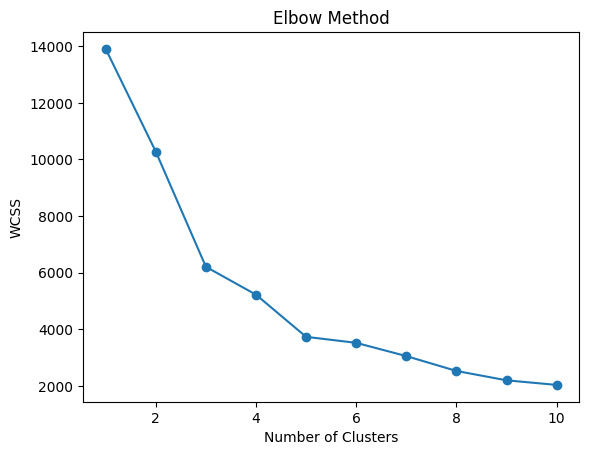

In [10]:
wcss = [] #Within-Cluster Sum of Squares
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(clustering_data)
    wcss.append(kmeans.inertia_)  # WCSS

# Plot the Elbow Method
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

From the graph above, it appears that 4 is the optimal number of clusters for the K-Means model.

In [11]:
kmeans = KMeans(n_clusters=4,random_state=88)
customer_profile["Cluster"]= kmeans.fit_predict(clustering_data)
print(customer_profile)

      CustomerID  Recency  Frequency  Monetary         Country  Cluster
0        12346.0      325          2      0.00  United Kingdom        0
1        12347.0        1        182   4310.00   Other Country        2
2        12348.0       74         31   1797.24   Other Country        2
3        12349.0       18         73   1757.55   Other Country        2
4        12350.0      309         17    334.40   Other Country        0
...          ...      ...        ...       ...             ...      ...
4367     18280.0      277         10    180.60  United Kingdom        0
4368     18281.0      180          7     80.82  United Kingdom        0
4369     18282.0        7         13    176.60  United Kingdom        2
4370     18283.0        3        721   2045.53  United Kingdom        2
4371     18287.0       42         70   1837.28  United Kingdom        2

[4372 rows x 6 columns]


### Cluster Analysis
First, we group the data by clusters and calculate the mean for numeric features and the mode for categorical features. Then, we visualize these features to uncover meaningful insights and patterns within the clusters.

In [12]:
# Analyze cluster characteristics
cluster_summary = customer_profile.drop("CustomerID",axis=1).groupby('Cluster').mean(numeric_only=True)
print("Numeric Cluster Summary:")
print(cluster_summary)



Numeric Cluster Summary:
            Recency   Frequency       Monetary
Cluster                                       
0        245.376471    27.41267     463.657675
1          1.000000  5824.25000   64463.562500
2         38.941989   105.26550    2009.863021
3          8.000000  1012.20000  192037.944000


### Visualize

<ipython-input-13-399197c2da4c>:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('tab10', len(clusters))  # Using 'tab10' for distinct colors


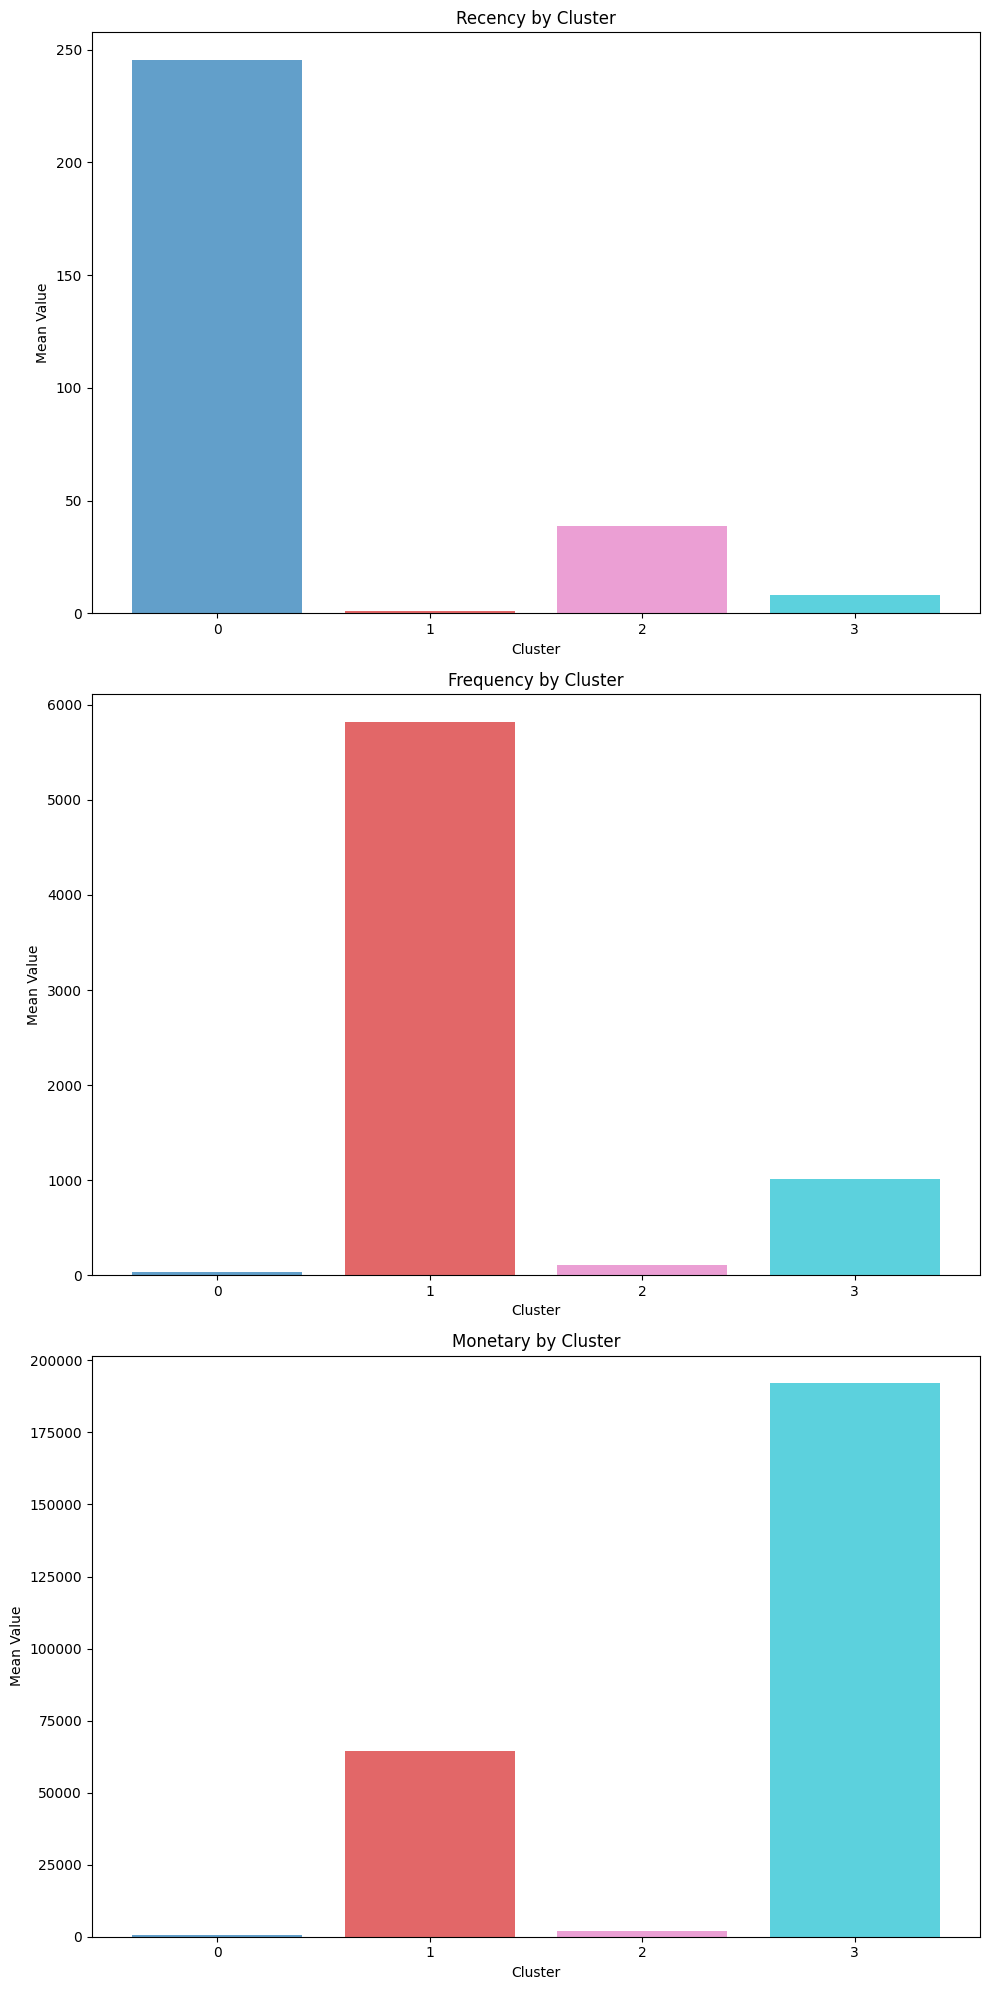

In [13]:
# Plot bar chart for cluster summary
features = cluster_summary.columns
clusters = cluster_summary.index

# Define a colormap
colors = cm.get_cmap('tab10', len(clusters))  # Using 'tab10' for distinct colors

# Create subplots
fig, axes = plt.subplots(nrows=len(features), ncols=1, figsize=(10,20))

for i, feature in enumerate(features):
    bar_colors = [colors(c) for c in clusters]

    axes[i].bar(clusters, cluster_summary[feature], color= bar_colors, alpha=0.7)
    axes[i].set_title(f"{feature} by Cluster")
    axes[i].set_xlabel("Cluster")
    axes[i].set_ylabel("Mean Value")
    axes[i].set_xticks(clusters)  # Set x-ticks to cluster labels (0, 1, 2, 3)
    axes[i].set_xticklabels([str(int(c)) for c in clusters])  # Ensure cluster labels are displayed as integers

# Adjust layout
plt.tight_layout()
plt.show()

According to the graphs above, we can make some traits for each cluster. \n  

*   Cluster 0:   Vary High Recency, Low purchase frequency, Low Monetary value
*   Cluster 1:   Low Recency, Very High purchase frequency,  High Monetary value
*   Cluster 2:   High Recency, Medium purchase frequency, Medium Monetary Value
*   Cluster 3:   Medium Recency, High purchase frequency, Very High Monetary Value



<ipython-input-14-b31497e5207a>:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_countries = country_cluster_counts.groupby('Cluster').apply(


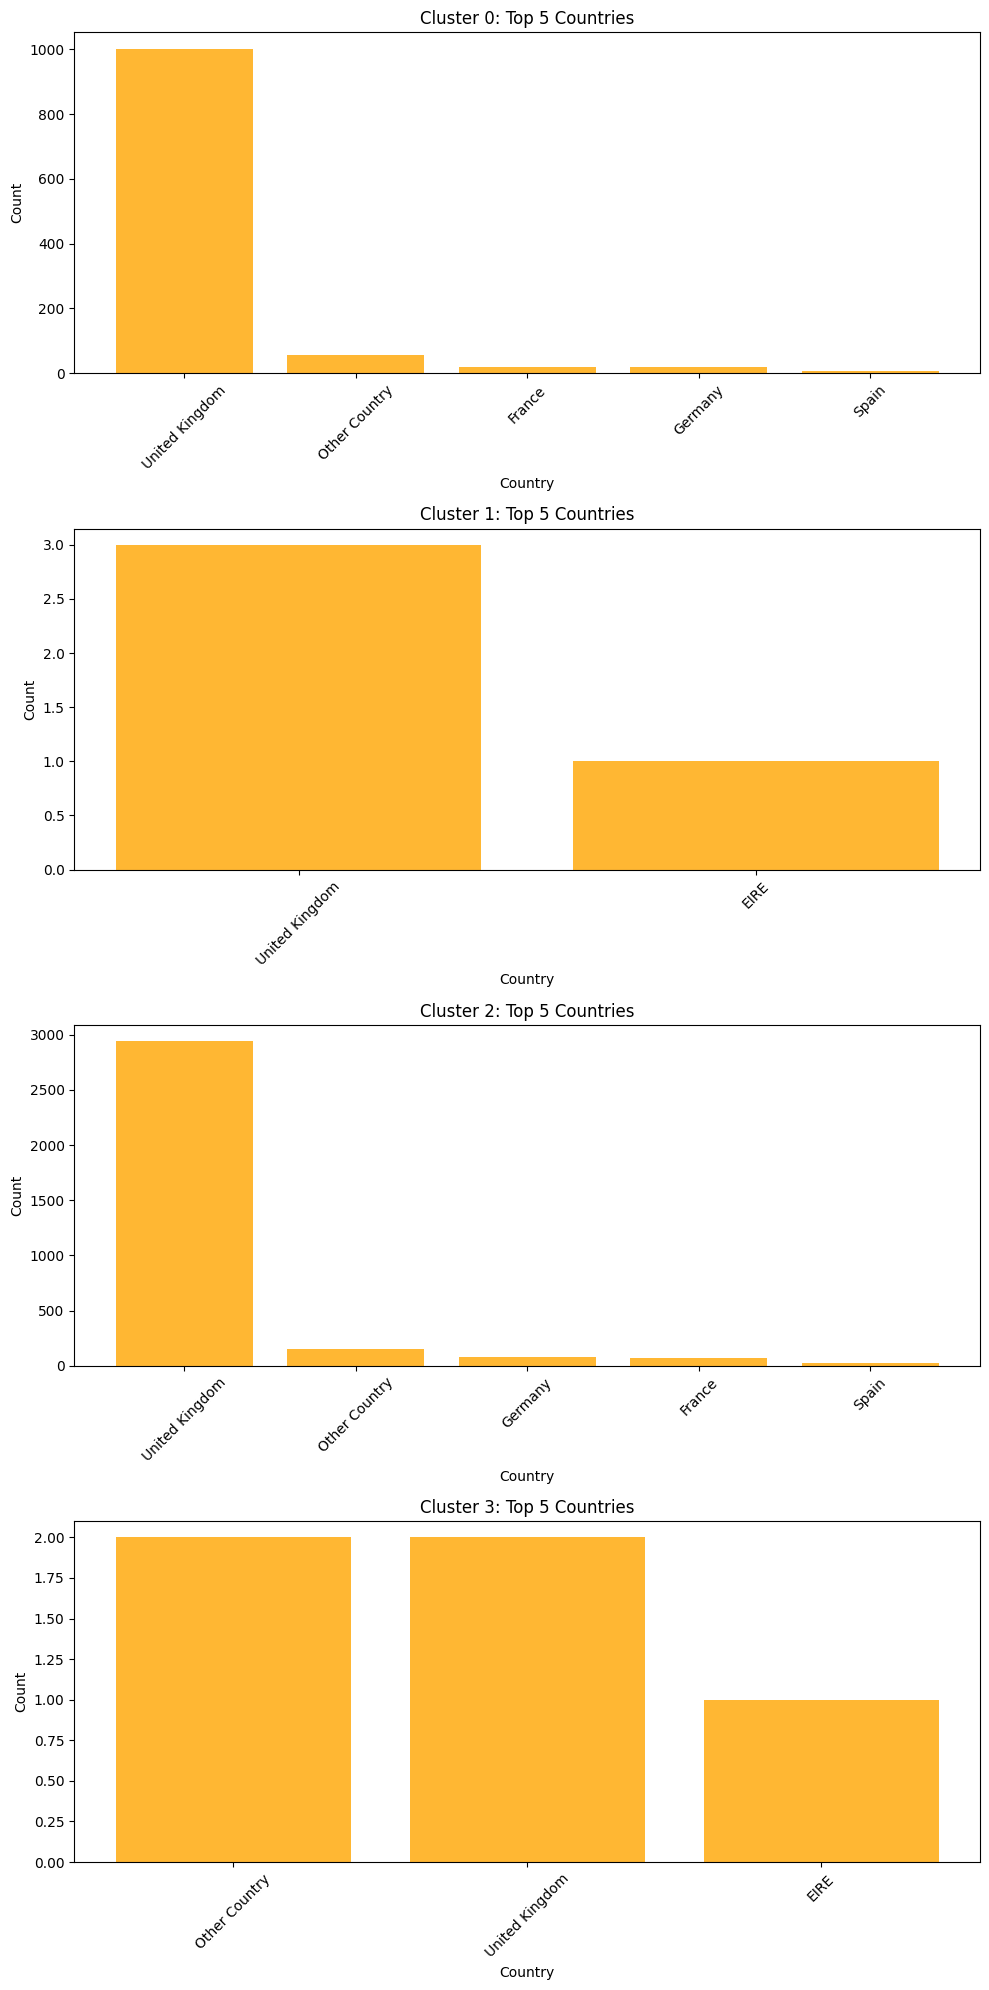

In [14]:
country_cluster_counts = customer_profile.groupby(['Country', 'Cluster']).size().reset_index(name='Count')

# Get top five countries for each cluster
top_countries = country_cluster_counts.groupby('Cluster').apply(
    lambda x: x.nlargest(5, 'Count')  # Select top 5 by 'Count'
).reset_index(drop=True)

# Create subplots for each cluster
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(10, 20))

clusters = top_countries['Cluster'].unique()

for i, cluster in enumerate(clusters):
    ax = axes[i]
    cluster_data = top_countries[top_countries['Cluster'] == cluster]
    ax.bar(cluster_data['Country'], cluster_data['Count'], color='orange', alpha=0.8)
    ax.set_title(f'Cluster {cluster}: Top 5 Countries')
    ax.set_xlabel('Country')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

We can see that the majority of the customers made the purchase in the United Kingdom. With these graphs, we can investigate further into the market in theese countries.

# Predict Customer Lifetime Value

I will be performing regression on Monetory Value where it is aslo consider the Customer Lifetime Value. These are the steps I took:



1.   Data Cleaning (Remove Missing Value, Remove Duplicates, Remove Outliers)
2.   Data Splitting
3.   Feature Engineering (Scaling and Encoding)
4.   Correlation Analysis
5.   Model Training and Evaluation (include Grid Search)
6.   Interpret Result (Visualize and Feature Importance)


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [16]:
customer_profile.head()

,CustomerID,Recency,Frequency,Monetary,Country,Cluster
0,12346.0,325,2,0.00,United Kingdom,0
1,12347.0,1,182,4310.00,Other Country,2
2,12348.0,74,31,1797.24,Other Country,2
3,12349.0,18,73,1757.55,Other Country,2
4,12350.0,309,17,334.40,Other Country,0


### Visualzie distribution of features and target varaible

In [17]:
def plot_distribution(data, column, bins=30, color='green', log_transform=False, title=None, xlabel=None, ylabel=None):
    """
    Plots the histogram of a column with an option for log transformation.

    Parameters:
        data (pd.DataFrame): The DataFrame containing the column to plot.
        column (str): The name of the column to plot.
        bins (int): Number of bins for the histogram (default: 30).
        color (str): Color of the bars in the histogram (default: 'green').
        log_transform (bool): If True, log-transform the data before plotting (default: False).
        title (str): Title of the plot (optional).
        xlabel (str): Label for the x-axis (optional).
        ylabel (str): Label for the y-axis (optional).
    """
    # Apply log transformation if requested
    if log_transform:
        data_to_plot = np.log1p(data[column])
        plot_title = title if title else f'Log-Transformed Distribution of {column}'
        plot_xlabel = xlabel if xlabel else f'Log({column})'
    else:
        data_to_plot = data[column]
        plot_title = title if title else f'Distribution of {column}'
        plot_xlabel = xlabel if xlabel else column

    # Plot the histogram
    plt.figure(figsize=(10, 6))
    plt.hist(data_to_plot, bins=bins, color=color, edgecolor='black', alpha=0.7)
    plt.title(plot_title)
    plt.xlabel(plot_xlabel)
    plt.ylabel(ylabel if ylabel else 'Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

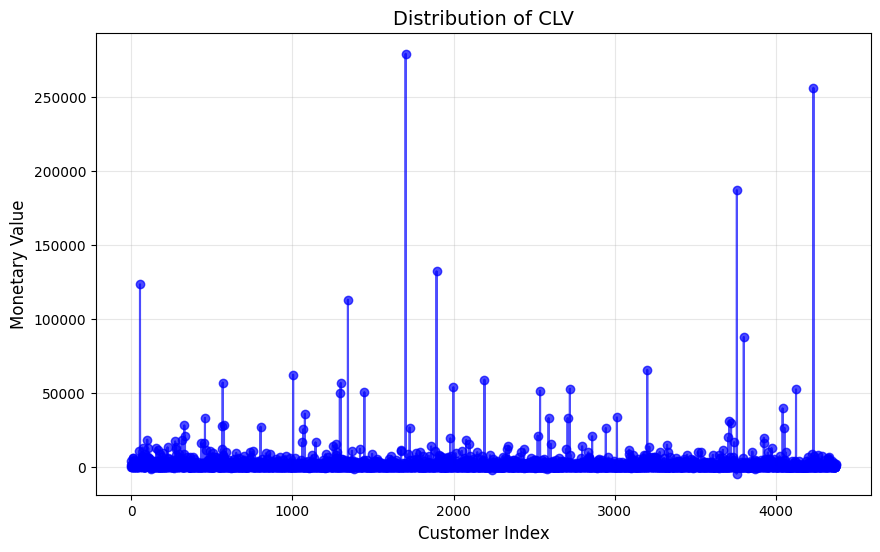

In [18]:
plt.figure(figsize=(10, 6))
plt.plot(customer_profile['Monetary'], marker='o', linestyle='-', color='blue', alpha=0.7)
plt.title('Distribution of CLV', fontsize=14)
plt.xlabel('Customer Index', fontsize=12)
plt.ylabel('Monetary Value', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

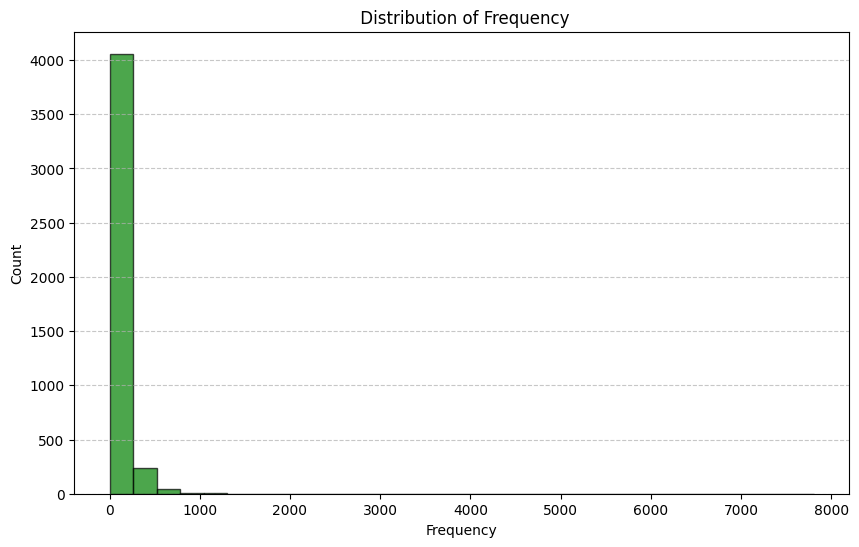

In [19]:
plot_distribution(data=customer_profile, column='Frequency', bins=30, color='green', log_transform=False, title=' Distribution of Frequency', xlabel='Frequency', ylabel='Count')

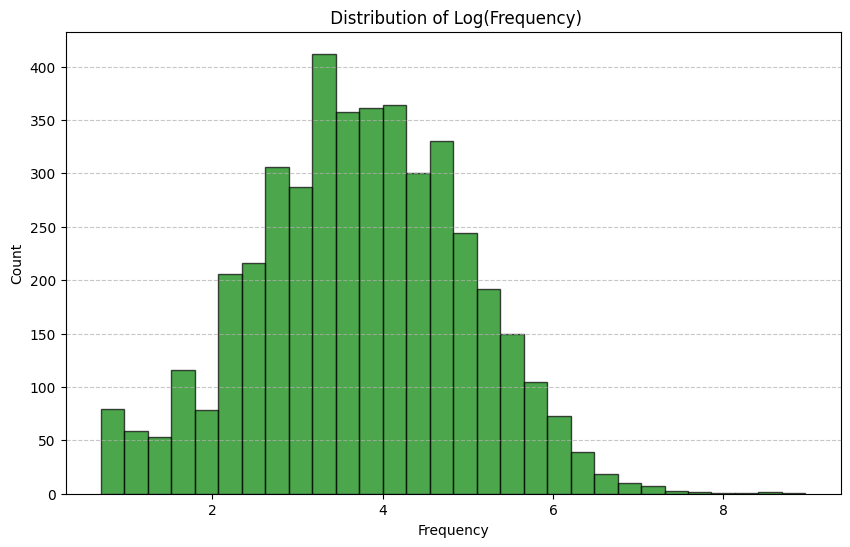

In [20]:
plot_distribution(data=customer_profile, column='Frequency', bins=30, color='green', log_transform=True, title=' Distribution of Log(Frequency)', xlabel='Frequency', ylabel='Count')

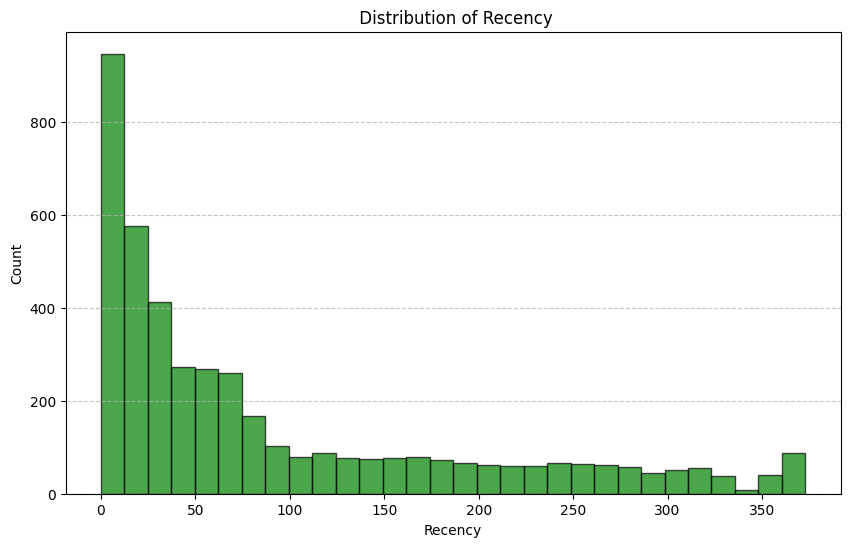

In [21]:
plot_distribution(data=customer_profile, column='Recency', bins=30, color='green', log_transform=False, title=' Distribution of Recency', xlabel='Recency', ylabel='Count')

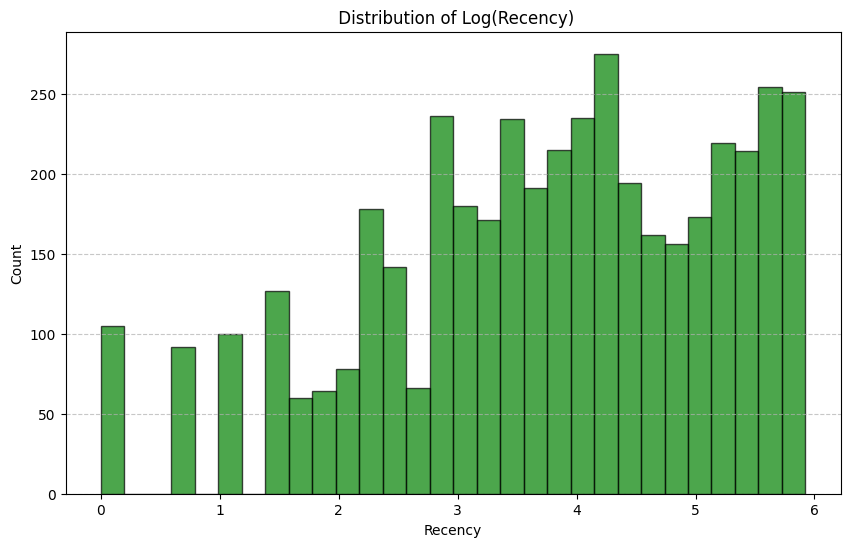

In [22]:
plot_distribution(data=customer_profile, column='Recency', bins=30, color='green', log_transform=True, title=' Distribution of Log(Recency)', xlabel='Recency', ylabel='Count')

The features Recency and Frequency are right-skewed, which could affect the performance of the regression model. Applying a log transformation to these features may help normalize their distribution and potentially improve the model's performance.

### Visualize Outliers

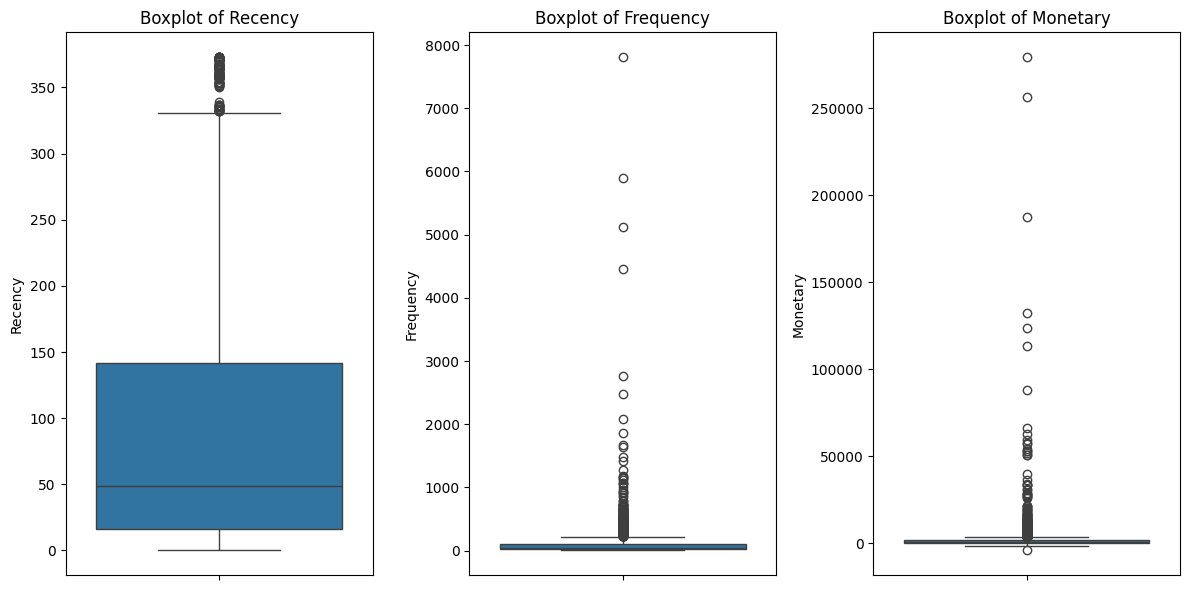

In [23]:
# Select numerical columns
numerical_columns = ['Recency', 'Frequency', 'Monetary']

# Create boxplots for each numerical column
plt.figure(figsize=(12, 6))
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=col, data=customer_profile)
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

As we can see, there are a significant number of outliers in the data. Therefore, I will remove the outliers for Recency and Frequency, as regression models are highly susceptible to being influenced by them. However, I believe removing outliers for the target variable would be inappropriate, as it could lead to the loss of valuable information about customers who contribute significantly to the company's profits. The only exception would be if the objective of the task is specifically focused on the majority of customers with lower customer lifetime values, in which case addressing those outliers might align better with the goal.

### Handling Outliers

In [24]:
# Remove Outliers

numerical_columns = ['Recency', 'Frequency']

# Calculate bounds for both features
lower_bounds = customer_profile[numerical_columns].quantile(0.05)
upper_bounds = customer_profile[numerical_columns].quantile(0.95)

# Filter rows that satisfy conditions for all features
customer_profile_filtered = customer_profile[
    (customer_profile['Recency'] >= lower_bounds['Recency']) &
    (customer_profile['Recency'] <= upper_bounds['Recency']) &
    (customer_profile['Frequency'] >= lower_bounds['Frequency']) &
    (customer_profile['Frequency'] <= upper_bounds['Frequency'])
]

print("Data after removing outliers:")
print(customer_profile_filtered.shape)

Data after removing outliers:
(3644, 6)


### Data Splitting

In [25]:
#Split Train & Val
X = customer_profile_filtered.drop(["CustomerID", "Monetary"	],axis=1)
y = customer_profile_filtered["Monetary"]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=88)

X_train.shape, X_val.shape, y_train.shape, y_val.shape

((2915, 4), (729, 4), (2915,), (729,))

### Scaling and Encoding
I will be encoding the Cluster as well because the cluster numbers represent categorical labels rather than ordinal or meaningful numerical relationships

In [26]:
# Initialize encoders and scaler
cluster_encoder = OneHotEncoder(sparse_output=False)
country_encoder = OneHotEncoder(sparse_output=False)
scaler = StandardScaler()

# Function to preprocess data (applies to both train and validation sets)
def preprocess_data(data, is_train=True, cluster_encoder=None, country_encoder=None, scaler=None):
    # One-Hot Encoding for Cluster
    encoded_cluster = cluster_encoder.transform(data[['Cluster']]) if not is_train else cluster_encoder.fit_transform(data[['Cluster']])
    encoded_cluster_df = pd.DataFrame(encoded_cluster, columns=cluster_encoder.get_feature_names_out(['Cluster']), index=data.index)

    # One-Hot Encoding for Country
    encoded_country = country_encoder.transform(data[['Country']]) if not is_train else country_encoder.fit_transform(data[['Country']])
    encoded_country_df = pd.DataFrame(encoded_country, columns=country_encoder.get_feature_names_out(['Country']), index=data.index)

    # Standard Scaling for RF features
    rfm_scaled = scaler.transform(data[['Frequency', 'Recency']]) if not is_train else scaler.fit_transform(data[['Frequency', 'Recency']])
    rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency_scaled', 'Frequency_scaled'], index=data.index)

    # Combine encoded and scaled features
    processed_data = pd.concat([data, encoded_cluster_df, encoded_country_df, rfm_scaled_df], axis=1)

    # Drop original unprocessed columns
    processed_data = processed_data.drop(['Cluster', 'Country', 'Frequency', 'Recency'], axis=1)

    return processed_data

# Preprocess X_train and X_val
X_train_encoded = preprocess_data(X_train, is_train=True, cluster_encoder=cluster_encoder, country_encoder=country_encoder, scaler=scaler)
X_val_encoded = preprocess_data(X_val, is_train=False, cluster_encoder=cluster_encoder, country_encoder=country_encoder, scaler=scaler)

# Verify the processed DataFrames
print("Encoded and Scaled Training Data:")
print(X_train_encoded.head())

print("\nEncoded and Scaled Validation Data:")
print(X_val_encoded.head())

Encoded and Scaled Training Data:
      Cluster_0  Cluster_2  Country_EIRE  Country_France  Country_Germany  \
320         1.0        0.0           0.0             0.0              0.0   
1757        0.0        1.0           0.0             0.0              0.0   
547         1.0        0.0           0.0             0.0              0.0   
966         0.0        1.0           0.0             0.0              0.0   
742         0.0        1.0           0.0             0.0              0.0   

      Country_Other Country  Country_Spain  Country_United Kingdom  \
320                     1.0            0.0                     0.0   
1757                    0.0            0.0                     1.0   
547                     0.0            0.0                     1.0   
966                     0.0            0.0                     1.0   
742                     0.0            0.0                     1.0   

      Recency_scaled  Frequency_scaled  
320        -0.657990          1.786931  


### Correlation Analysis

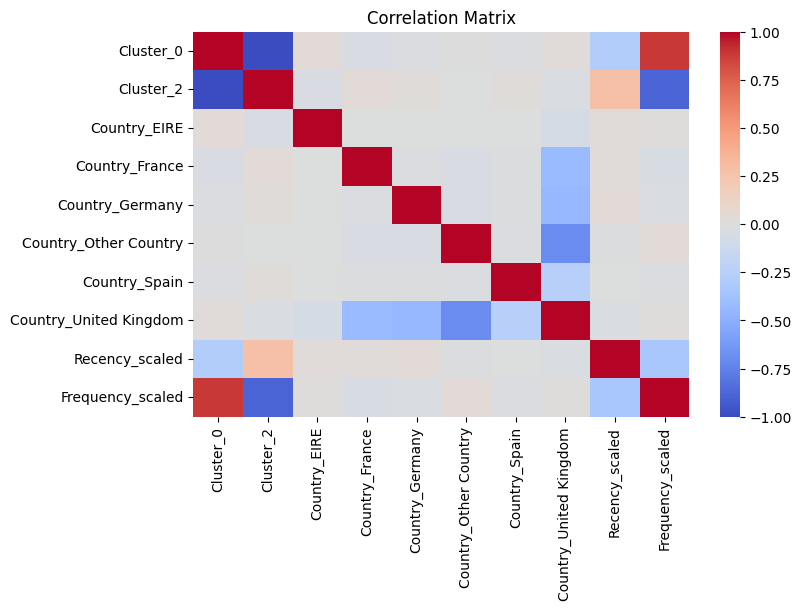

In [27]:
# Plot Correlation heatmap
correlation_matrix = X_train_encoded.corr()
plt.figure(figsize=(8, 5))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Cluster_0  and Recency_scaled are highly correlated so I might consider remove one of it in the future based on the model performance.

### Model Building
I will experiment with multiple algorithms to determine which performs best on the validation set. Additionally, I will use grid search to identify the optimal hyperparameters for each algorithm.

In [28]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
from joblib import dump

In [29]:
# Initialize variables to track the best model and lowest MSE
best_model_name = None
lowest_mse = float('inf')
best_model = None

# Store results for all models
best_models = {}
grid_search_results = {}

# Define models
models = {
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "ElasticNet": ElasticNet(),
    "LinearRegression": LinearRegression(),
    "DecisionTreeRegressor": DecisionTreeRegressor(),
    "RandomForestRegressor": RandomForestRegressor()  # Random Forest included
}

# Parameter grids for GridSearchCV
param_grids = {
    "Ridge": {"alpha": [0.1, 1.0, 10.0]},
    "Lasso": {"alpha": [0.01, 0.1, 1.0]},
    "ElasticNet": {"alpha": [0.01, 0.1, 1.0], "l1_ratio": [0.1, 0.5, 0.9]},
    "LinearRegression": {},  # No hyperparameters for LinearRegression
    "DecisionTreeRegressor": {"max_depth": [3, 5, 10], "min_samples_split": [2, 5, 10]},
    "RandomForestRegressor": {
        "n_estimators": [50, 100, 200],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5, 10]
    }
}

# Perform Grid Search for each model
for model_name, model in models.items():
    print(f"Running GridSearchCV for {model_name}...")
    param_grid = param_grids.get(model_name, {})

    # Skip models without parameter grids (e.g., LinearRegression)
    if not param_grid:
        print(f"{model_name} has no hyperparameters to tune. Skipping GridSearchCV.")
        model.fit(X_train_encoded, y_train)
        y_pred = model.predict(X_val_encoded)
        mse = mean_squared_error(y_val, y_pred)
        grid_search_results[model_name] = {"Best Parameters": "None", "MSE": mse}
        best_models[model_name] = model

        # Check if this is the best model
        if mse < lowest_mse:
            lowest_mse = mse
            best_model_name = model_name
            best_model = model

        continue

    # Perform Grid Search
    grid_search = GridSearchCV(model, param_grid, scoring="neg_mean_squared_error", cv=5)
    grid_search.fit(X_train_encoded, y_train)

    # Store the best model and results
    best_models[model_name] = grid_search.best_estimator_
    y_pred = grid_search.best_estimator_.predict(X_val_encoded)
    mse = mean_squared_error(y_val, y_pred)
    grid_search_results[model_name] = {
        "Best Parameters": grid_search.best_params_,
        "MSE": mse,
    }

    # Check if this is the best model
    if mse < lowest_mse:
        lowest_mse = mse
        best_model_name = model_name
        best_model = grid_search.best_estimator_

# Save the best model
print(f"\nThe best model is {best_model_name} with MSE = {lowest_mse:.4f}")
dump(best_model, f"{best_model_name}_best_model.joblib")
print(f"The best model has been saved as {best_model_name}_best_model.joblib")

# Display Grid Search Results
print("\nGrid Search Results:")
for model_name, result in grid_search_results.items():
    print(f"{model_name}: Best Parameters = {result['Best Parameters']}, MSE = {result['MSE']:.4f}")


Running GridSearchCV for Ridge...
Running GridSearchCV for Lasso...


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.085e+08, tolerance: 1.809e+06
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.690e+08, tolerance: 1.378e+06
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.453e+08, tolerance: 1.734e

Running GridSearchCV for ElasticNet...
Running GridSearchCV for LinearRegression...
LinearRegression has no hyperparameters to tune. Skipping GridSearchCV.
Running GridSearchCV for DecisionTreeRegressor...
Running GridSearchCV for RandomForestRegressor...

The best model is ElasticNet with MSE = 3069136.7308
The best model has been saved as ElasticNet_best_model.joblib

Grid Search Results:
Ridge: Best Parameters = {'alpha': 10.0}, MSE = 3101031.4916
Lasso: Best Parameters = {'alpha': 1.0}, MSE = 3101268.9801
ElasticNet: Best Parameters = {'alpha': 0.1, 'l1_ratio': 0.5}, MSE = 3069136.7308
LinearRegression: Best Parameters = None, MSE = 3104714.4366
DecisionTreeRegressor: Best Parameters = {'max_depth': 3, 'min_samples_split': 2}, MSE = 3796822.4538
RandomForestRegressor: Best Parameters = {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 200}, MSE = 5035012.8886


ElasticNet outperformed the other models, making it the selected model for this analysis. However, the Mean Squared Error (MSE) indicates that the model's performance could be improved, as it deviates significantly from the actual values, with an MSE of 3,069,136.7308. Additionally, I experimented with applying a log transformation to the numerical features before inputting them into the model. Surprisingly, the model performed worse with the log-transformed features compared to using the original ones, suggesting that the original scale of the features was more suitable for this dataset.

### Visualize result

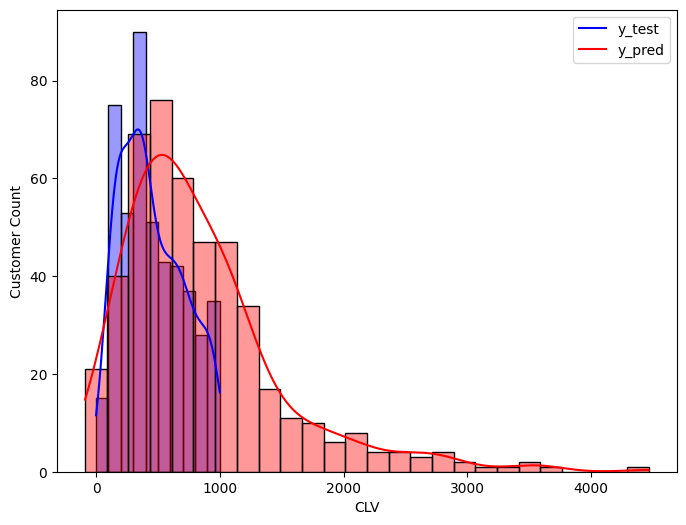

In [30]:
y_pred = best_model.predict(X_val_encoded)
predictions = pd.DataFrame({'y_val': y_val.array, 'y_pred': y_pred})
predictions = predictions[(predictions['y_val'] > 0) & (predictions['y_val'] < 1000)]

# plot predictions against the actual value
plt.figure(figsize=(8, 6))
sns.histplot(data=predictions, x='y_val', kde=True, color='blue', alpha=0.4)
sns.histplot(data=predictions, x='y_pred', kde=True, color='red', alpha=0.4)

plt.legend(['y_test', 'y_pred'])
plt.xlabel('CLV')
plt.ylabel('Customer Count')
plt.show()

The graph compares the actual customer lifetime value (y_test, in blue) with the predicted customer lifetime value (y_pred, in red) from my regression model. I noticed that the predicted values have their peak shifted slightly to the right, suggesting that my model tends to overestimate smaller customer lifetime values. Additionally, the predicted distribution has a longer tail, which indicates overprediction for customers with higher lifetime values. This mismatch is particularly noticeable for extreme values, where the model seems to struggle with accurately predicting the actual distribution of customer lifetime value. At the same time, there is some underprediction for lower ranges, as the actual values peak higher than the predictions.


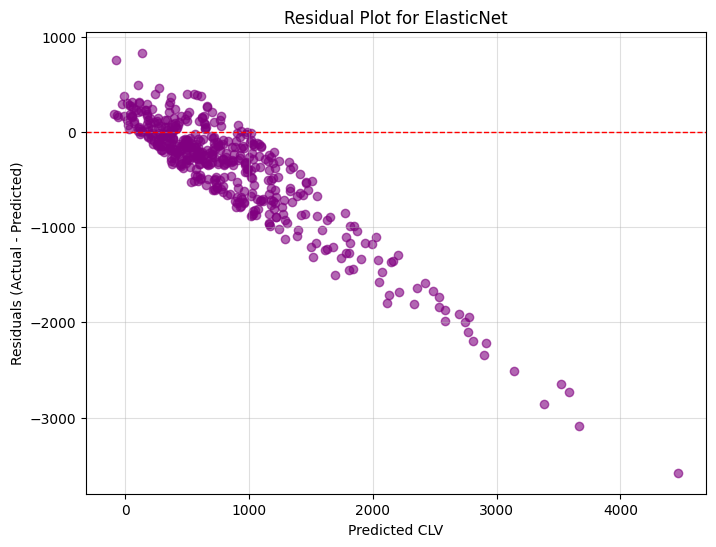

In [31]:
# Calculate residuals
residuals = predictions['y_val'] - predictions['y_pred']

# Plot residuals
plt.figure(figsize=(8, 6))
plt.scatter(predictions['y_pred'], residuals, alpha=0.6, color='purple')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel('Predicted CLV')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot for ElasticNet')
plt.grid(alpha=0.4)
plt.show()


There is a noticeable systematic bias, as the residuals are not randomly scattered around the red dashed line at 0. Instead, they show a clear downward trend, indicating that the model tends to overpredict smaller CLV values and underpredict larger ones. Additionally, the spread of residuals increases as the predicted CLV grows, suggesting the presence of heteroscedasticity, where the model's errors are inconsistent across different levels of the target variable. This inconsistency highlights the model's difficulty in accurately predicting high-value customers. Furthermore, there are extreme negative residuals for larger predicted CLV values, which may represent genuine outliers or reflect the model's inability to effectively capture the behavior of high-value customers.

### Feature Importance

In [32]:
from sklearn.inspection import permutation_importance
result = permutation_importance(best_model, X_val_encoded, y_val, scoring='neg_mean_squared_error')
result_df = pd.DataFrame(result.importances_mean, index=X_val_encoded.columns, columns=['Importance'])
result_df = result_df.sort_values(by='Importance', ascending=False)
print(result_df)

                          Importance
Recency_scaled          1.859062e+06
Frequency_scaled        3.131356e+04
Country_United Kingdom  2.920609e+04
Country_Other Country   6.592133e+03
Cluster_2               5.896144e+03
Cluster_0               5.895424e+03
Country_Germany         2.711911e+02
Country_Spain           3.859525e+01
Country_EIRE            0.000000e+00
Country_France         -3.081127e+02



We can evaluate which features have a negative or minimal impact on the model's performance. From the analysis, it appears that features such as Country_EIRE and Country_France contribute little to no impact on the model. By identifying and selecting only the important features, we can refine the model, potentially improving its performance and efficiency.

### Conclusion

In conclusion, I believe the primary factor contributing to the model's weak performance is the presence of outliers in the target variable. Building separate models for different clusters could be a more effective approach, as a single model may not perform well across all customer segments. Additionally, removing extreme outliers from the dataset is likely to improve the results, as my experiments with varying the number of outliers have demonstrated a positive impact on model performance.